# RTDA — float32 vs bfloat16 on AIE-ML

`aieml_batch` is built at two precisions from the same ONNX weights. This notebook answers
the only question that matters about the switch: **what does bf16 buy, and what does it
cost?**

Both precisions are compared against **one reference** — `mlp_fp32.onnx`, the physics
model — so the two columns are directly comparable. The reference itself is float32; that
is the point, since it is the thing both designs are trying to reproduce.

| | fp32 | bf16 |
|---|---|---|
| source tree | `src_fp32/` | `src_bf16/` |
| `aie::mmul` microtile | 4x8x4 | 4x8x4 (same → BATCH stays 8) |
| weights | float32 | bfloat16 (stored as `uint16_t` bit patterns) |
| biases | float32 | **float32** (unchanged) |
| accumulator / event mean | float32 | **float32** (`track_accum` widens on load) |

Only the dense stack's data path changes. Everything downstream of the average — the host
dense, the output format, this analysis — is identical, which is what makes the comparison
clean.

**Prerequisite:** run `rtda_reference.ipynb` first, or at least its §3, which writes
`out/golden_onnx_50000.npz`. This notebook loads that rather than rebuilding it.


## 0. Setup


In [1]:
import collections, sys, warnings
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
np.set_printoptions(precision=6, suppress=True, linewidth=120)

REPO = Path.cwd()
while not (REPO / 'data_fp32').is_dir() and REPO != REPO.parent:
    REPO = REPO.parent
DATA   = REPO / 'data_fp32'
BATCHD = REPO / 'aieml_batch'
SIMOUT = BATCHD / 'results' / 'sim_events'
OUTD   = BATCHD / 'notebooks' / 'out'
OUTD.mkdir(parents=True, exist_ok=True)

H, TRACKS_PER_EVENT, SLOTS_PER_EVENT, OUT_DIM, WARMUP = 128, 50, 56, 27, 3
COL = {'fp32': 'tab:blue', 'bf16': 'tab:red'}

Wo = np.loadtxt(DATA / 'output_weights.txt').astype(np.float64).reshape(H, OUT_DIM)
Bo = np.loadtxt(DATA / 'output_bias.txt').astype(np.float64)
out27 = lambda m: np.asarray(m) @ Wo + Bo      # host_batch.cpp convention

REF_NPZ = OUTD / 'golden_onnx_50000.npz'
assert REF_NPZ.exists(), f'{REF_NPZ} missing - run rtda_reference.ipynb §3 first'
_g = np.load(REF_NPZ)
REF_PT   = _g['per_track'].astype(np.float64)          # (1000, 50, 128)
REF27    = out27(REF_PT.mean(1))                       # all 50 tracks
REF27_W  = out27(REF_PT[:, WARMUP:].mean(1))           # tracks 3..49
N_EVENTS = REF_PT.shape[0]
FS       = np.abs(REF27).max()

print(f'reference : {REF_NPZ.name}  {N_EVENTS} events')
print(f'            27 outputs, full scale (largest |value|) = {FS:.5f}')
print(f'            with/without warm-up differ by {np.abs(REF27-REF27_W).max():.3e}'
      f'  <- the roll convention, present in BOTH precisions')


reference : golden_onnx_50000.npz  1000 events
            27 outputs, full scale (largest |value|) = 0.08568
            with/without warm-up differ by 1.556e-02  <- the roll convention, present in BOTH precisions


## 1. What ran

Everything found on disk. A precision needs at least one simulation (for the per-track
taps) and ideally the hardware run.


In [2]:
def load_sim(path):
    d = np.load(path)
    nev = int(d['n_events'])
    spe = int(d['slots_per_event']) if 'slots_per_event' in d else SLOTS_PER_EVENT
    off = int(d['flush_slots']) if 'flush_slots' in d else 0
    r = {'file': path.name, 'n_events': nev, 'mean': d['measured'].astype(np.float64)}
    if 's2_out' in d:
        a = d['s2_out'].astype(np.float64)
        if len(a) >= off + nev * spe:
            r['per_track'] = a[off:off+nev*spe].reshape(nev, spe, H)[:, :TRACKS_PER_EVENT, :]
    return r

def load_hw(d):
    d = Path(d)
    f = d / 'track_means_all.txt'
    if not f.exists():
        return None
    with f.open() as fh:
        n_ev, n_col = (int(x) for x in fh.readline().split())
    info = {}
    ri = d / 'run_info.txt'
    if ri.exists():
        for line in ri.read_text().splitlines():
            if '=' in line:
                k, v = line.split('=', 1)
                try:    info[k] = float(v)
                except ValueError: info[k] = v
    return {'file': f.name, 'n_events': n_ev,
            'mean': np.loadtxt(f, skiprows=1).reshape(n_ev, n_col), 'info': info}

# DISCOVER the runs, never hard-code file names. sim_events.py writes
#   sim_<sim>_<precision>_<N>ev_<T>tr.npz
# but older runs predate the precision tag and are named sim_<sim>_<N>ev_<T>tr.npz.
# Reading the precision out of the npz (with a filename fallback) means a clean
# rebuild, a legacy file, or a mix of both all work.
def discover(simout):
    found = collections.defaultdict(dict)
    for f in sorted(simout.glob('sim_*ev_*tr.npz')):
        d = np.load(f)
        sim  = str(d['sim']) if 'sim' in d else ('x86' if '_x86_' in f.name else 'aie')
        prec = str(d['precision']) if 'precision' in d else ('bf16' if '_bf16_' in f.name else 'fp32')
        nev  = int(d['n_events'])
        # prefer a run with per-track taps, then the one closest to 5 events
        key = ('s2_out' in d, nev == 5, nev)
        cur = found[prec].get(sim)
        if cur is None or key > cur[0]:
            found[prec][sim] = (key, f)
    return {p: {s: load_sim(v[1]) for s, v in d.items()} for p, d in found.items()}

RUNS = collections.defaultdict(dict, discover(SIMOUT))
for prec, dirn in (('fp32', BATCHD/'results'/'hw'), ('bf16', BATCHD/'results'/'hw_bf16')):
    hw = load_hw(dirn)
    if hw:
        RUNS[prec]['hw'] = hw

for prec in ('fp32', 'bf16'):
    print(f'{prec}:')
    for sim in ('x86', 'aie', 'hw'):
        r = RUNS[prec].get(sim)
        if r is None:
            print(f'    {sim:4s} -- missing')
        else:
            pt = ' + per-track' if 'per_track' in r else ''
            print(f'    {sim:4s} {r["n_events"]:5d} events{pt}   ({r["file"]})')


fp32:
    x86      5 events + per-track   (sim_x86_5ev_250tr.npz)
    aie      5 events + per-track   (sim_aie_5ev_250tr.npz)
    hw    1000 events   (track_means_all.txt)
bf16:
    x86      5 events + per-track   (sim_x86_bf16_5ev_250tr.npz)
    aie      5 events + per-track   (sim_aie_bf16_5ev_250tr.npz)
    hw    1000 events   (track_means_all.txt)


## 2. Accuracy — the 27 outputs vs the ONNX golden

The deliverable is the 27-dim output after the average and the host-side dense. Two
conventions, because the roll-concat differs from the reference by construction:

- **with warm-up** — the mean over all 50 tracks, which is what the hardware emits;
- **without warm-up** — tracks 3..49 only. Needs per-track data, so simulation only.

Tracks 0-2 of every event use the streaming roll rather than the reference's circular one.
That difference is present in *both* precisions and is not an arithmetic error, so the
without-warm-up column is the one that isolates precision.


In [3]:
rows = []
for prec in ('fp32', 'bf16'):
    for sim in ('x86', 'aie', 'hw'):
        r = RUNS[prec].get(sim)
        if r is None:
            continue
        n = r['n_events']
        e_all = np.abs(out27(r['mean']) - REF27[:n]).max()
        e_w = np.abs(out27(r['per_track'][:, WARMUP:].mean(1)) - REF27_W[:n]).max() \
              if 'per_track' in r else None
        rows.append((prec, sim, n, e_all, e_w))

print(f'{"":5s} {"":5s} {"events":>7s} {"WITH warm-up":>14s} {"WITHOUT warm-up":>17s} {"% of full scale":>16s}')
print('-' * 70)
for prec, sim, n, a, w in rows:
    ws = f'{w:17.3e}' if w is not None else f'{"n/a":>17s}'
    pc = f'{100*w/FS:15.3f}%' if w is not None else f'{"":>16s}'
    print(f'  {prec:4s} {sim:4s} {n:7d} {a:14.3e} {ws} {pc}')
print('-' * 70)
print(f'  {"reference against itself":<24s} {np.abs(REF27-REF27_W).max():14.3e}'
      f'   <- the roll convention alone')

fp = next((w for p, s, n, a, w in rows if p == 'fp32' and w is not None), None)
bf = next((w for p, s, n, a, w in rows if p == 'bf16' and w is not None), None)
if fp and bf:
    print(f'\n  bf16 is {bf/fp:.0f}x further from the golden than fp32 '
          f'({bf:.3e} vs {fp:.3e})')


             events   WITH warm-up   WITHOUT warm-up  % of full scale
----------------------------------------------------------------------
  fp32 x86        5      6.920e-03         7.534e-07           0.001%
  fp32 aie        5      6.920e-03         7.534e-07           0.001%
  fp32 hw      1000      1.273e-02               n/a                 
  bf16 x86        5      6.816e-03         3.963e-04           0.463%
  bf16 aie        5      6.816e-03         3.963e-04           0.463%
  bf16 hw      1000      1.307e-02               n/a                 
----------------------------------------------------------------------
  reference against itself      1.556e-02   <- the roll convention alone

  bf16 is 526x further from the golden than fp32 (3.963e-04 vs 7.534e-07)


### Per output, not just full scale

"% of full scale" divides by the largest of the 27 outputs, which flatters bf16: the
outputs have very different spreads. Judging each against **its own** event-to-event
variation is stricter and more useful — an error comparable to an output's own spread
destroys the information in it.


output spreads (std across 1000 events): 0.00052 .. 0.01523   (29x range)

fp32: worst output = index 6 at 0.0% of its own spread
bf16: worst output = index 26 at 7.6% of its own spread


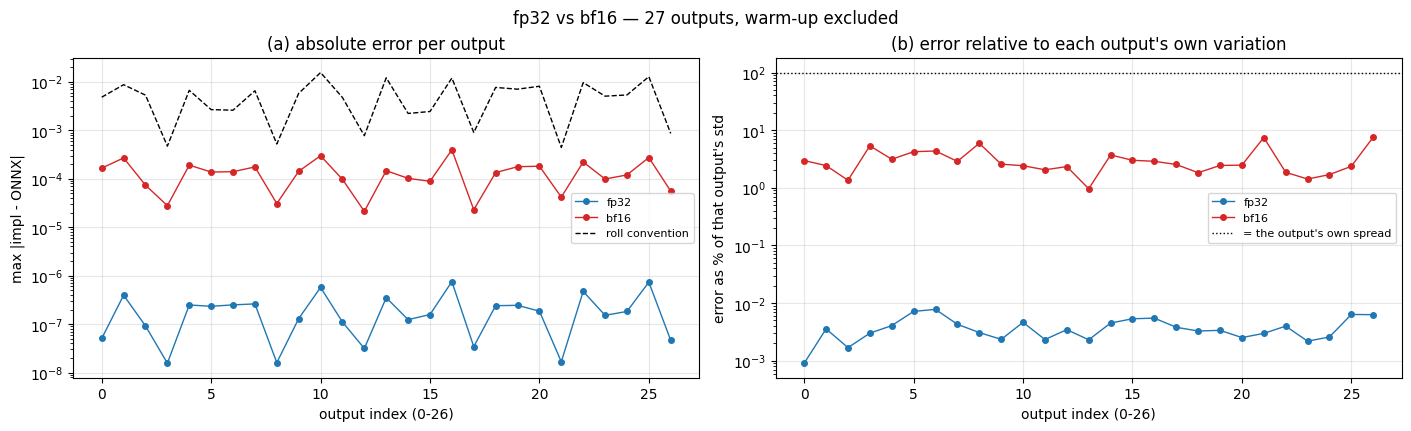

In [4]:
std = REF27_W.std(0)                       # (27,) spread of each output across events
print(f'output spreads (std across {N_EVENTS} events): '
      f'{std.min():.5f} .. {std.max():.5f}   ({std.max()/std.min():.0f}x range)\n')

fig, ax = plt.subplots(1, 2, figsize=(14, 4.2), constrained_layout=True)
for prec in ('fp32', 'bf16'):
    r = next((RUNS[prec][s] for s in ('x86', 'aie') if s in RUNS[prec]
              and 'per_track' in RUNS[prec][s]), None)
    if r is None:
        continue
    n = r['n_events']
    err = np.abs(out27(r['per_track'][:, WARMUP:].mean(1)) - REF27_W[:n]).max(axis=0)
    ax[0].semilogy(err, 'o-', ms=4, lw=1, color=COL[prec], label=prec)
    ax[1].semilogy(100 * err / std, 'o-', ms=4, lw=1, color=COL[prec], label=prec)
    print(f'{prec}: worst output = index {int((err/std).argmax())} at '
          f'{100*(err/std).max():.1f}% of its own spread')

ax[0].semilogy(np.abs(REF27 - REF27_W).max(axis=0), 'k--', lw=1, label='roll convention')
ax[0].set_xlabel('output index (0-26)'); ax[0].set_ylabel('max |impl - ONNX|')
ax[0].set_title('(a) absolute error per output'); ax[0].legend(fontsize=8); ax[0].grid(alpha=.3)

ax[1].axhline(100, color='k', ls=':', lw=1, label="= the output's own spread")
ax[1].set_xlabel('output index (0-26)'); ax[1].set_ylabel("error as % of that output's std")
ax[1].set_title("(b) error relative to each output's own variation")
ax[1].legend(fontsize=8); ax[1].grid(alpha=.3)
fig.suptitle('fp32 vs bf16 — 27 outputs, warm-up excluded', fontsize=12)
fig.savefig(OUTD / 'bf16_accuracy_per_output.png', dpi=140, bbox_inches='tight')
plt.show()


## 3. Hardware — 1000 events each

Both precisions ran the same 50,000-track stimulus on silicon. Only the with-warm-up
comparison exists here (no per-track taps in the system build), so the absolute level is
dominated by the roll convention in both columns — what to look at is whether bf16 sits
*above* fp32, and by how much.


fp32 hardware: 1000 events   worst 1.273e-02   median 4.149e-03
bf16 hardware: 1000 events   worst 1.307e-02   median 4.189e-03


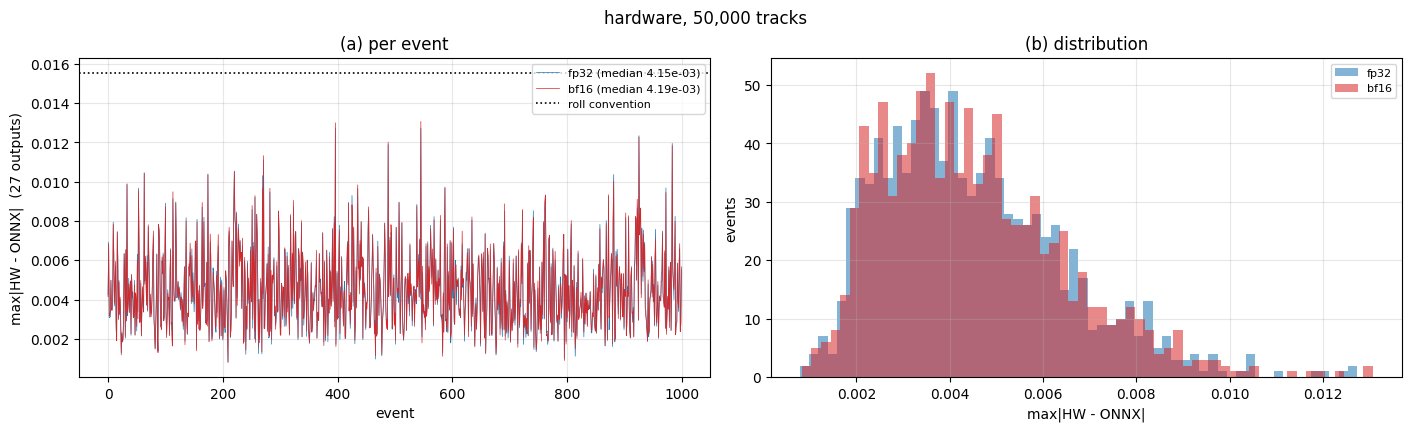

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4.2), constrained_layout=True)
for prec in ('fp32', 'bf16'):
    hw = RUNS[prec].get('hw')
    if hw is None:
        continue
    n = min(hw['n_events'], N_EVENTS)
    e = np.abs(out27(hw['mean'][:n]) - REF27[:n]).max(axis=1)
    ax[0].plot(e, lw=.5, color=COL[prec], label=f'{prec} (median {np.median(e):.2e})')
    ax[1].hist(e, bins=60, alpha=.55, color=COL[prec], label=prec)
    print(f'{prec} hardware: {n} events   worst {e.max():.3e}   median {np.median(e):.3e}')

ax[0].axhline(np.abs(REF27-REF27_W).max(), color='k', ls=':', lw=1.2, label='roll convention')
ax[0].set_xlabel('event'); ax[0].set_ylabel('max|HW - ONNX|  (27 outputs)')
ax[0].set_title('(a) per event'); ax[0].legend(fontsize=8); ax[0].grid(alpha=.3)
ax[1].set_xlabel('max|HW - ONNX|'); ax[1].set_ylabel('events')
ax[1].set_title('(b) distribution'); ax[1].legend(fontsize=8); ax[1].grid(alpha=.3)
fig.suptitle(f'hardware, 50,000 tracks', fontsize=12)
fig.savefig(OUTD / 'bf16_hw_accuracy.png', dpi=140, bbox_inches='tight')
plt.show()


In [6]:
# do the two precisions agree with EACH OTHER on hardware? they share everything but the
# dense data path, so this isolates precision from every other difference
if 'hw' in RUNS['fp32'] and 'hw' in RUNS['bf16']:
    a, b = RUNS['fp32']['hw']['mean'], RUNS['bf16']['hw']['mean']
    n = min(len(a), len(b))
    d = np.abs(out27(a[:n]) - out27(b[:n])).max(axis=1)
    print(f'fp32 vs bf16 on hardware, {n} events (27 outputs)')
    print(f'  worst {d.max():.3e}   median {np.median(d):.3e}   = {100*d.max()/FS:.3f}% of full scale')
    print('\n  This is the pure precision difference: same stimulus, same weights, same')
    print('  roll, same accumulator. Everything else cancels.')


fp32 vs bf16 on hardware, 1000 events (27 outputs)
  worst 8.005e-04   median 3.363e-04   = 0.934% of full scale

  This is the pure precision difference: same stimulus, same weights, same
  roll, same accumulator. Everything else cancels.


## 4. Performance

`run_info.txt` from each board run, plus the cycle-accurate II from `make report`.


In [7]:
II_NS = {'fp32': 4161.0, 'bf16': 1033.0}      # aiesimulator, `make report`
MACS_PER_TRACK, ITER_PER_EVENT = 264192, 7

print(f'{"":6s} {"II (ns)":>9s} {"ns/track":>10s} {"ns/track":>10s} {"GOP/s":>9s} {"RTP":>9s} {"input":>9s}')
print(f'{"":6s} {"cyc-acc":>9s} {"cyc-acc":>10s} {"silicon":>10s} {"silicon":>9s} {"weights":>9s} {"bytes":>9s}')
print('-' * 62)
perf = {}
for prec in ('fp32', 'bf16'):
    ii = II_NS[prec]
    model_ns = ii * ITER_PER_EVENT / TRACKS_PER_EVENT
    hw = RUNS[prec].get('hw')
    info = hw['info'] if hw else {}
    perf[prec] = dict(ii=ii, model_ns=model_ns,
                      hw_ns=info.get('us_per_track', float('nan')) * 1000,
                      gops=info.get('gops', float('nan')),
                      rtp=info.get('rtp_bytes', float('nan')),
                      inb=info.get('in_bytes', float('nan')),
                      exec_us=info.get('us_execute', float('nan')))
    p = perf[prec]
    print(f'  {prec:4s} {ii:9.0f} {model_ns:10.1f} {p["hw_ns"]:10.1f} {p["gops"]:9.0f}'
          f' {p["rtp"]/1024:8.0f}K {p["inb"]/1024:8.0f}K')
print('-' * 62)
f, b = perf['fp32'], perf['bf16']
print(f'  speedup   {f["ii"]/b["ii"]:8.2f}x {f["model_ns"]/b["model_ns"]:9.2f}x'
      f' {f["hw_ns"]/b["hw_ns"]:9.2f}x {b["gops"]/f["gops"]:8.2f}x'
      f' {f["rtp"]/b["rtp"]:8.2f}x {f["inb"]/b["inb"]:8.2f}x')

print(f"""
The cycle-accurate speedup is {f['ii']/b['ii']:.2f}x but silicon delivers {f['hw_ns']/b['hw_ns']:.2f}x.
The gap is data movement: bf16 makes the ARRAY ~4x faster, so the DMA and the
per-graph.run() host cost -- unchanged by precision -- take a bigger share. The same
effect is visible in the per-port report, where the event tail became the slowest stage.""")


         II (ns)   ns/track   ns/track     GOP/s       RTP     input
         cyc-acc    cyc-acc    silicon   silicon   weights     bytes
--------------------------------------------------------------
  fp32      4161      582.5      615.4       859     1039K     3504K
  bf16      1033      144.6      244.5      2161      523K     1752K
--------------------------------------------------------------
  speedup       4.03x      4.03x      2.52x     2.52x     1.99x     2.00x

The cycle-accurate speedup is 4.03x but silicon delivers 2.52x.
The gap is data movement: bf16 makes the ARRAY ~4x faster, so the DMA and the
per-graph.run() host cost -- unchanged by precision -- take a bigger share. The same
effect is visible in the per-port report, where the event tail became the slowest stage.


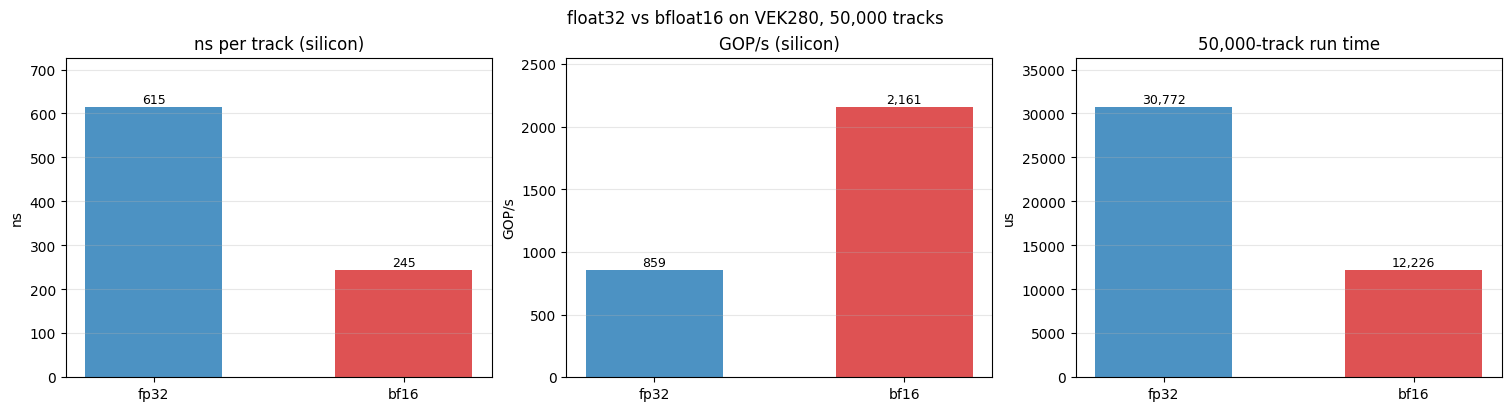

In [8]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
labels = ['fp32', 'bf16']
x = np.arange(2)
for k, (key, title, unit) in enumerate([('hw_ns', 'ns per track (silicon)', 'ns'),
                                        ('gops', 'GOP/s (silicon)', 'GOP/s'),
                                        ('exec_us', '50,000-track run time', 'us')]):
    vals = [perf[p][key] for p in labels]
    bars = ax[k].bar(x, vals, color=[COL[p] for p in labels], alpha=.8, width=.55)
    ax[k].set_xticks(x); ax[k].set_xticklabels(labels)
    ax[k].set_ylabel(unit); ax[k].set_title(title); ax[k].grid(alpha=.3, axis='y')
    for bar, v in zip(bars, vals):
        ax[k].text(bar.get_x() + bar.get_width()/2, v, f'{v:,.0f}',
                   ha='center', va='bottom', fontsize=9)
    ax[k].set_ylim(0, max(vals) * 1.18)
fig.suptitle('float32 vs bfloat16 on VEK280, 50,000 tracks', fontsize=12)
fig.savefig(OUTD / 'bf16_performance.png', dpi=140, bbox_inches='tight')
plt.show()


## 5. Verdict


In [9]:
w_fp = next((w for p, s, n, a, w in rows if p == 'fp32' and w is not None), float('nan'))
w_bf = next((w for p, s, n, a, w in rows if p == 'bf16' and w is not None), float('nan'))
r = next((RUNS['bf16'][s] for s in ('x86','aie') if s in RUNS['bf16']
          and 'per_track' in RUNS['bf16'][s]), None)
worst_rel = (np.abs(out27(r['per_track'][:, WARMUP:].mean(1))
                    - REF27_W[:r['n_events']]).max(axis=0) / std).max() * 100 if r else float('nan')

print(f"""  bf16 vs fp32, measured

  FASTER      {perf['fp32']['hw_ns']/perf['bf16']['hw_ns']:.2f}x on silicon  ({perf['fp32']['hw_ns']:.0f} -> {perf['bf16']['hw_ns']:.0f} ns/track)
              {perf['fp32']['ii']/perf['bf16']['ii']:.2f}x in the array alone (II {perf['fp32']['ii']:.0f} -> {perf['bf16']['ii']:.0f} ns)
              {perf['bf16']['gops']/perf['fp32']['gops']:.2f}x throughput ({perf['fp32']['gops']:.0f} -> {perf['bf16']['gops']:.0f} GOP/s)

  SMALLER     weights {perf['fp32']['rtp']/1024:.0f}K -> {perf['bf16']['rtp']/1024:.0f}K, input DMA halved

  LESS EXACT  27 outputs, warm-up excluded: {w_fp:.2e} -> {w_bf:.2e}  ({w_bf/w_fp:.0f}x)
              = {100*w_bf/FS:.2f}% of full scale
              = up to {worst_rel:.0f}% of the narrowest output's own spread   <- the real limit

  The narrow outputs are where bf16 hurts. If your analysis uses all 27 equally,
  that number decides it; if it leans on the wide ones, bf16 is close to free.""")


  bf16 vs fp32, measured

  FASTER      2.52x on silicon  (615 -> 245 ns/track)
              4.03x in the array alone (II 4161 -> 1033 ns)
              2.52x throughput (859 -> 2161 GOP/s)

  SMALLER     weights 1039K -> 523K, input DMA halved

  LESS EXACT  27 outputs, warm-up excluded: 7.53e-07 -> 3.96e-04  (526x)
              = 0.46% of full scale
              = up to 8% of the narrowest output's own spread   <- the real limit

  The narrow outputs are where bf16 hurts. If your analysis uses all 27 equally,
  that number decides it; if it leans on the wide ones, bf16 is close to free.


### What is not measured here

- **bf16 aiesimulator over 5 events** — only the single-event `make crosscheck` was run,
  so there is no `sim_aie_bf16_5ev_250tr.npz`. The x86 numbers stand in; x86 and
  aiesimulator agreed bit-for-bit at fp32, so this is very likely representative, but it
  is an assumption rather than a measurement.
- **Resource usage** — tiles, memory and columns come from `Map_Report.csv` / the mapper
  section of `log.<P>`, which needs a `make graph PRECISION=<P>` for each. bf16 should use
  fewer memory tiles (half the weight bytes) but the same compute tiles.
- **Warm-up-excluded accuracy on silicon** — impossible without per-track taps in the
  system build.
